<a href="https://colab.research.google.com/github/shohjahon71/toshkent_housing/blob/main/predict_house.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Toshkent shahrida uylarning narxini aniqlash

In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [71]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


# Ma'lumotlarni o'rganamiz, analiz qilib va kerakli o'zgartrishlarni bajaramiz

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


Yuqoridagi m'lumotlardan 'size' (o'lcham) va 'price' (narx) ustunlari object ekanligini ko'rishimiz mumkin. Bu ustunlarni sonli ustunlarga o'zgartrish kerak.

In [73]:
df_n = df
df_f = df_n.drop(['location', 'district'], axis=1)
for col in list(df_f.columns):
       if type(col) != int:
            df_n[col] = pd.to_numeric(df_f[col], errors='coerce')

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    7565 non-null   object 
 1   district    7565 non-null   object 
 2   rooms       7565 non-null   int64  
 3   size        7564 non-null   float64
 4   level       7565 non-null   int64  
 5   max_levels  7565 non-null   int64  
 6   price       7466 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 413.8+ KB


# O'zgartrilgan ma'lumotlarimizni tekshiramiz.

In [75]:
df_n.isna().sum()

,0
location,0
district,0
rooms,0
size,1
level,0
max_levels,0
price,99


'size' ustunida bir dona va 'price' ustunida 99 ta NaN qiymatlar mavjud ekanini ko'ramiz. Barcha ustunlardagi NaN qiymatlarni tashlab yuboramiz.

In [76]:
df_n = df_n.dropna()
df_n.isna().sum()

,0
location,0
district,0
rooms,0
size,0
level,0
max_levels,0
price,0


NaN qiymatlar ustida ishladik. Endi ma'lumotlarni o'rganib chiqamiz.

In [77]:
print(f"max_size : {df_n['size'].max()}   min_size : {df_n['size'].min()}")

max_size : 70000.0   min_size : 1.0


Uylarning o'lchamlari normal oraliqda emas minimal o'cham 1 kv.metr desak max o'lcham 70000 kv.metr, bu judaham katta. Demak ma'lumotlarimizni filtrlashimiz kerak.

In [78]:
df_n[df_n['size']<15][df_n['rooms']>1]

/tmp/ipykernel_5774/2713091541.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_n[df_n['size']<15][df_n['rooms']>1]


,location,district,rooms,size,level,max_levels,price
796,"город Ташкент, Яккасарайский район, 1-й проезд...",Яккасарайский,2,5.0,1,4,50000.0
1588,"город Ташкент, Янгихаётский район, Yangi hayot...",Янгихаётский,5,1.0,6,9,45000.0
2147,"город Ташкент, Учтепинский район, Куксарой",Учтепинский,8,8.5,2,2,230000.0
2363,"город Ташкент, Мирабадский район, Nurli zamin ...",Мирабадский,4,3.0,1,1,50000.0
4053,"город Ташкент, Мирзо-Улугбекский район, Элобод",Мирзо-Улугбекский,2,4.0,1,3,26000.0
4337,"город Ташкент, Мирабадский район, Нукус",Мирабадский,3,5.0,4,5,46600.0
4690,"город Ташкент, Мирабадский район, 1-й проезд Х...",Мирабадский,5,3.8,2,2,90000.0
5496,"город Ташкент, Учтепинский район, Чиланзар 25-...",Учтепинский,2,1.0,2,5,35000.0


In [79]:
df_n[df_n['size']>250]

,location,district,rooms,size,level,max_levels,price
262,"город Ташкент, Мирабадский район, Нукус",Мирабадский,8,350.0,2,12,260000.0
307,"город Ташкент, Юнусабадский район, ц-5 Киёт (Ц...",Юнусабадский,5,255.0,1,8,270000.0
308,"город Ташкент, Юнусабадский район, ц-5 Киёт (Ц...",Юнусабадский,6,266.0,1,8,285000.0
741,"город Ташкент, Мирабадский район, Айбека (пр-т...",Мирабадский,5,300.0,3,8,425000.0
981,"город Ташкент, Мирабадский район, Массив Куйлю...",Мирабадский,3,7359.0,2,4,46500.0
1553,"город Ташкент, Мирабадский район, Шахрисабз",Мирабадский,4,280.0,4,8,320000.0
1557,"город Ташкент, Юнусабадский район, Минор",Юнусабадский,10,448.0,7,7,425600.0
1649,"город Ташкент, Шайхантахурский район, Ипакчи",Шайхантахурский,6,268.0,1,3,260000.0
1674,"город Ташкент, Яккасарайский район, Кичик Бешагач",Яккасарайский,3,265.0,1,9,198750.0
1675,"город Ташкент, Мирабадский район, Нукус",Мирабадский,8,350.0,2,12,260000.0


Oddatda 1 xonali uylarnig minimal o'lchami 10 kv.metr atrofida bo'ladi. Lekin bizga berilgan ma'lumotlarda 10 kv.m dan kichik va xonalari 2 va undan ortiq bo'lgan uylar mavjud. Bu ma'lumotlar bizning modelimizni noto'g'ri bashorat qilishiga tasir qilishi mumkin, shuning uchun bu ma'lumotlarni tashlab yuboramiz.

In [80]:
df_n = df_n.drop(df_n[df_n['size']<15][df_n['rooms']>1].index)
df_n = df_n.drop(df_n[df_n['size']>250].index)
df_n = df_n.drop(df_n[df_n['size']==2100].index)

/tmp/ipykernel_5774/4149483698.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_n = df_n.drop(df_n[df_n['size']<15][df_n['rooms']>1].index)


In [81]:
print(f"max_price : {df_n['price'].max()}   min_price : {df_n['price'].min()}")

max_price : 52000000.0   min_price : 2.0


Uylarning narxlaridaham ushbu nomutanosiblikni kuzatishimiz mumkin minimal narx 2 USD desak max narx 52000000 USD , buham juda katta. Ma'lumotlarimizni yana filtrlashimiz kerak.

In [82]:
df_n[df_n['price']<7000][df_n['rooms']>1]

/tmp/ipykernel_5774/2319351010.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_n[df_n['price']<7000][df_n['rooms']>1]


,location,district,rooms,size,level,max_levels,price
273,"город Ташкент, Яккасарайский район, Нукус",Яккасарайский,3,100.0,3,4,1000.0
3832,"город Ташкент, Яккасарайский район, Абдуллы Ка...",Яккасарайский,4,170.0,2,6,2000.0
5073,"город Ташкент, Сергелийский район, Srrgili 8uc...",Сергелийский,2,54.0,7,7,2864.0
5719,"город Ташкент, Шайхантахурский район, Караташ",Шайхантахурский,7,230.0,2,5,1000.0
7224,"город Ташкент, Учтепинский район, Чиланзар-11",Учтепинский,2,51.0,2,4,2.0


In [83]:
df_n[df_n['price']>200000]

,location,district,rooms,size,level,max_levels,price
189,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,4,187.0,2,5,210000.0
310,"город Ташкент, Яккасарайский район, Кичик Бешагач",Яккасарайский,4,210.0,4,8,265000.0
330,"город Ташкент, Яшнободский район, 1-й переулок...",Яшнободский,2,68.0,5,8,1666000.0
345,"город Ташкент, Мирабадский район, Окбилол",Мирабадский,4,165.0,1,8,264999.0
346,"город Ташкент, Мирабадский район, Янгизамон",Мирабадский,4,215.0,5,8,259999.0
...,...,...,...,...,...,...,...
6952,"город Ташкент, Шайхантахурский район, Алишера ...",Шайхантахурский,3,114.0,5,7,15504000.0
7081,"город Ташкент, Чиланзарский район, Тирсакобод",Чиланзарский,2,85.0,2,3,6630000.0
7296,"город Ташкент, Яшнободский район, Садыка Азимо...",Яшнободский,4,96.0,2,5,5568000.0
7466,"город Ташкент, Чиланзарский район, 1-й проезд ...",Чиланзарский,2,42.0,1,3,1470000.0


Demak xonalar soni 2 va undan ortiq lekin narxlari juda past va xonalar soni kam lekin narxi juda yuqori bo'lgan real narxga to'g'ri kelmaydigan uylarni ko'rishimiz mumkin. Bu uylarni ham tashlab yuboramiz.

In [84]:
df_n = df_n.drop(df_n[df_n['price']<7000][df_n['rooms']>1].index)
df_n = df_n.drop(df_n[df_n['price']>200000].index)

/tmp/ipykernel_5774/63190184.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_n = df_n.drop(df_n[df_n['price']<7000][df_n['rooms']>1].index)


# Filtrlangan ma'lumotlarimizni endi Grafik usulda taxlil qilamiz

In [85]:
df_n = df_n.reset_index(drop=True)

df_1 = df_n.drop(['location', 'district'], axis=1)

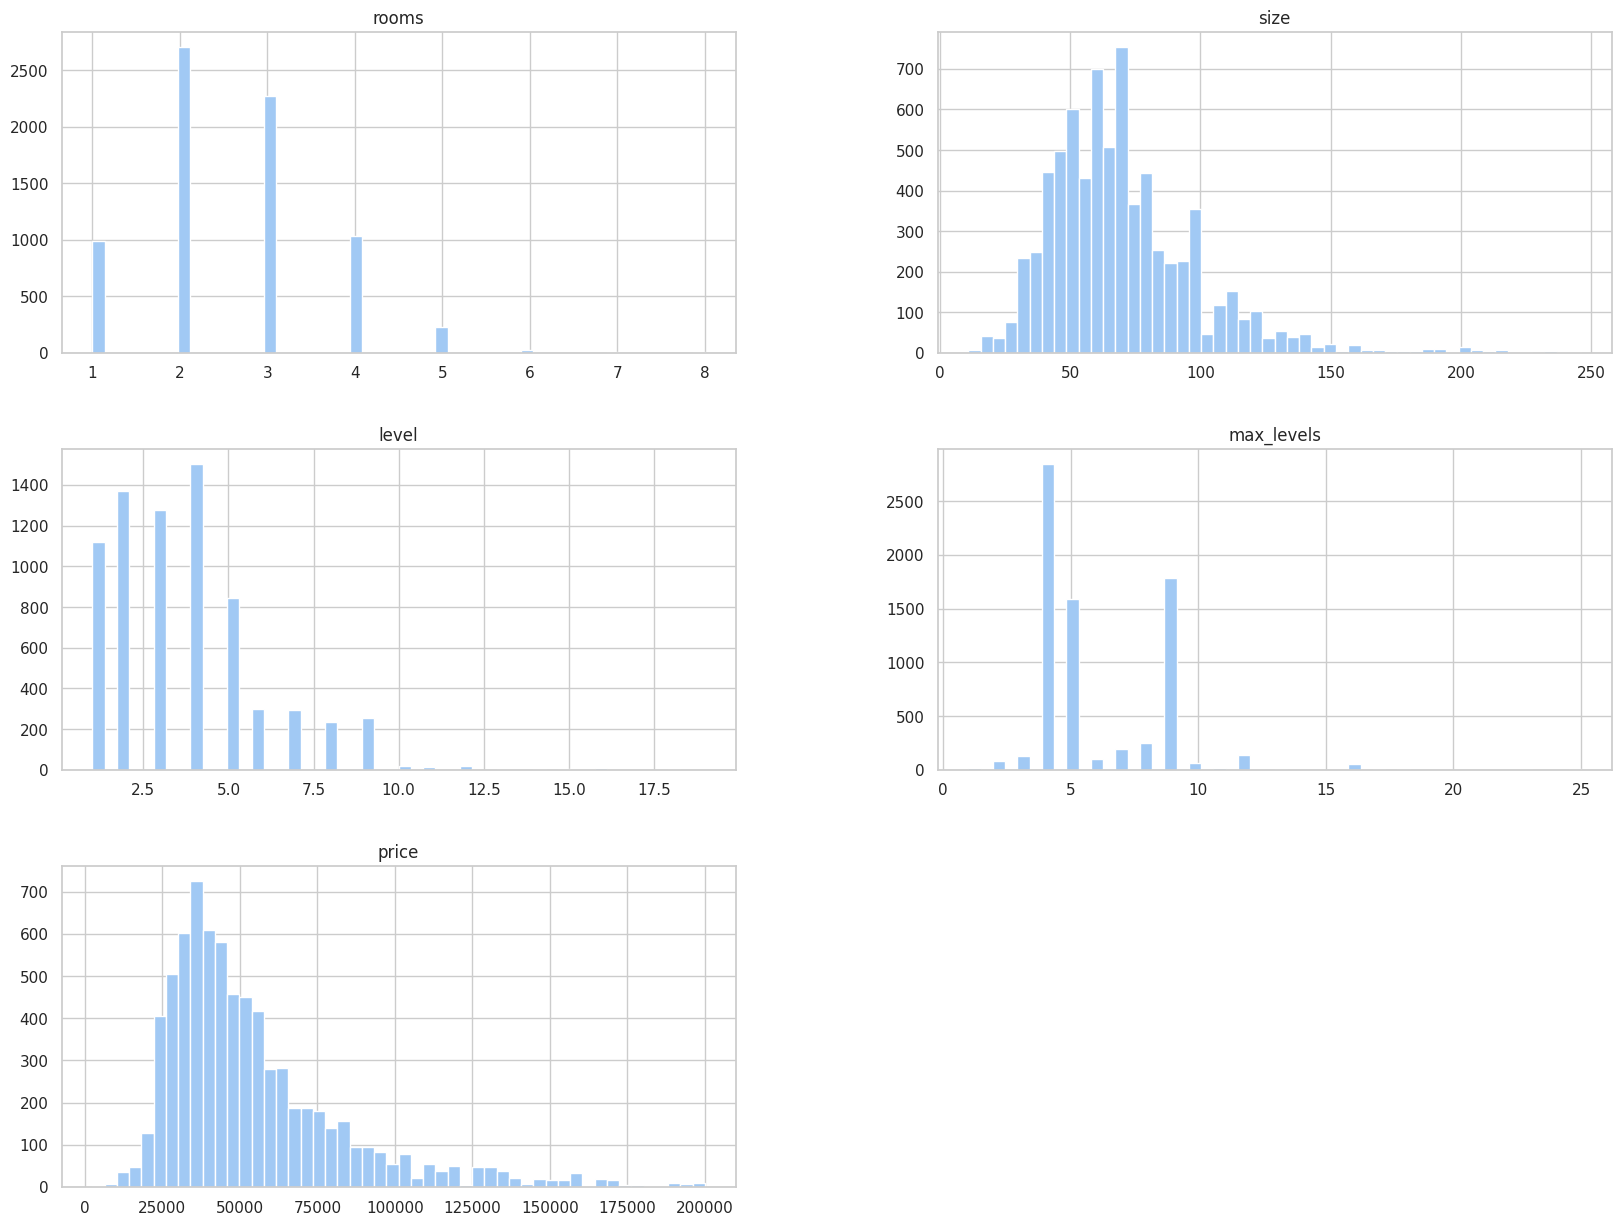

In [86]:
%matplotlib inline
df_1.hist(bins=50, figsize=(20,15))
plt.show()

#UYLARNING NARXI BO'YICHA

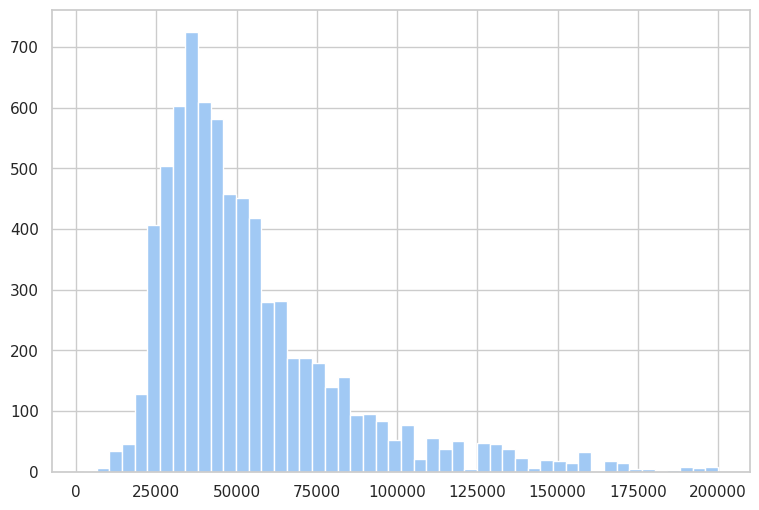

In [87]:
%matplotlib inline
df_p=df_n[['price']]
df_p['price'].hist(bins=50, figsize=(9,6))
plt.show()

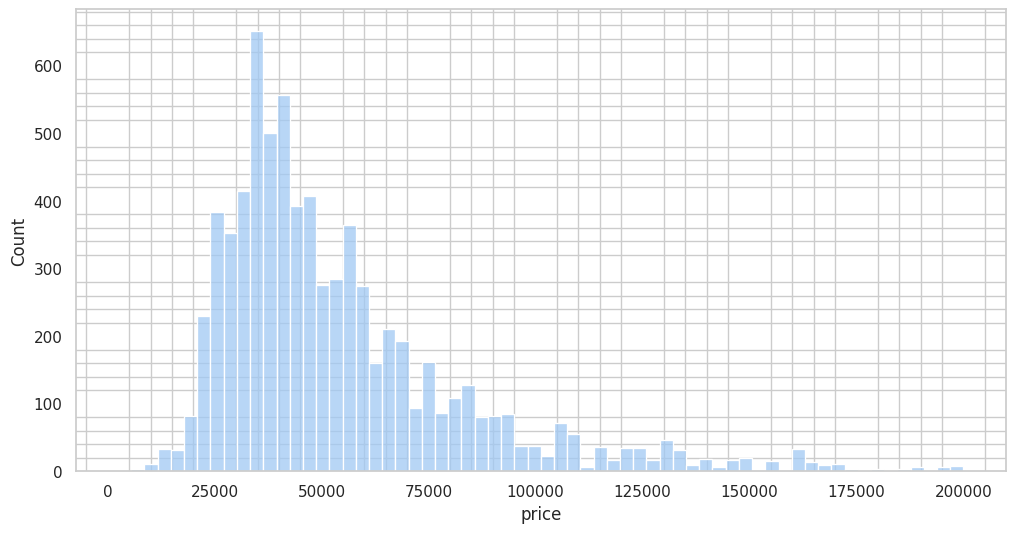

In [88]:
df_pf=df_n[df_n['price']<250000]
plt.figure(figsize=(12,6))
sns.histplot(data=df_pf, x='price')
plt.grid(which='both')
plt.minorticks_on()
plt.show()

Bu grafikdan 80 % ga yaqin uylarning narxi 20000 - 100000 USD oralig'ida ekanligini ko'rishimiz mumkin.

# UYLARNING MAYDONI BO'YICHA

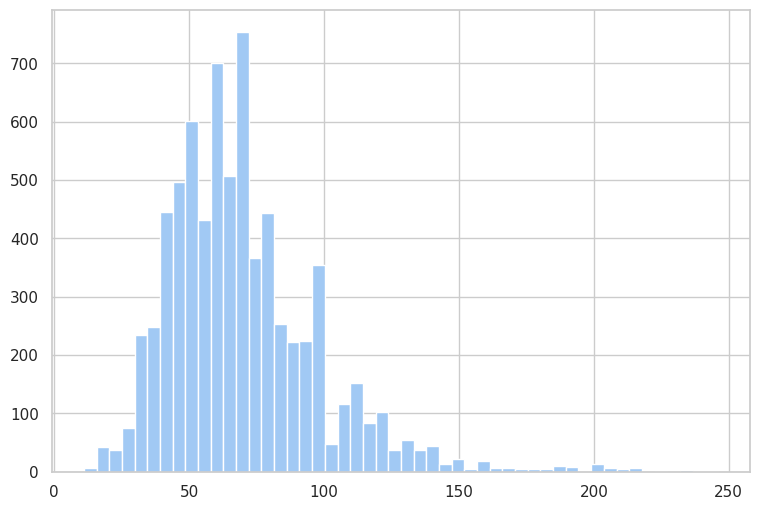

In [89]:
%matplotlib inline
df_s=df_n[['size']]
df_s['size'].hist(bins=50, figsize=(9,6))
plt.show()

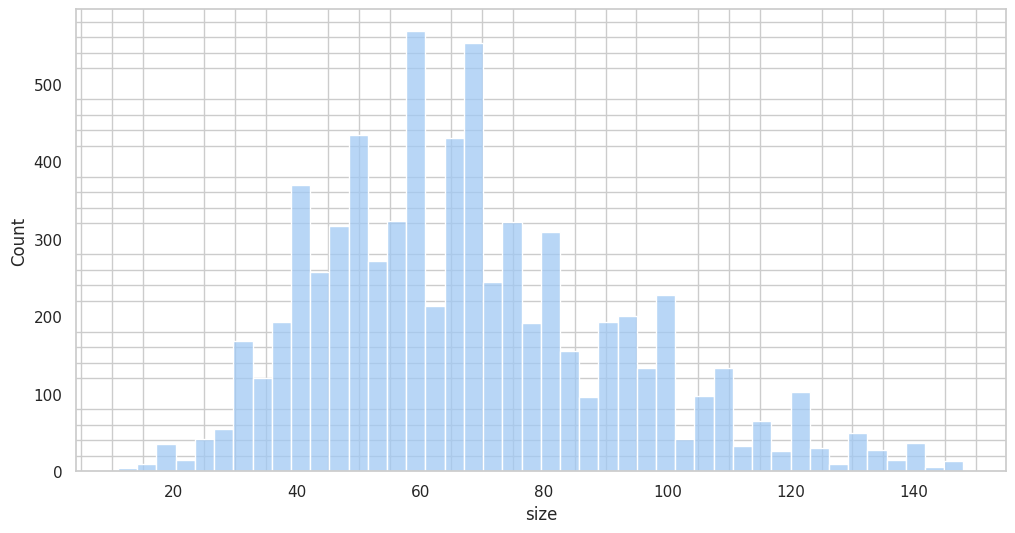

In [90]:
df_sf=df_n[df_n['size']<150]
plt.figure(figsize=(12,6))
sns.histplot(data=df_sf, x='size')
plt.grid(which='both')
plt.minorticks_on()
plt.show()

Bu grafikdan aksar uylarning maydoni 25 - 100 kv.metr oralig'ida ekanligini ko'rishimiz mumkin.

# UYLARNING XONALAR SONI BO'YICHA

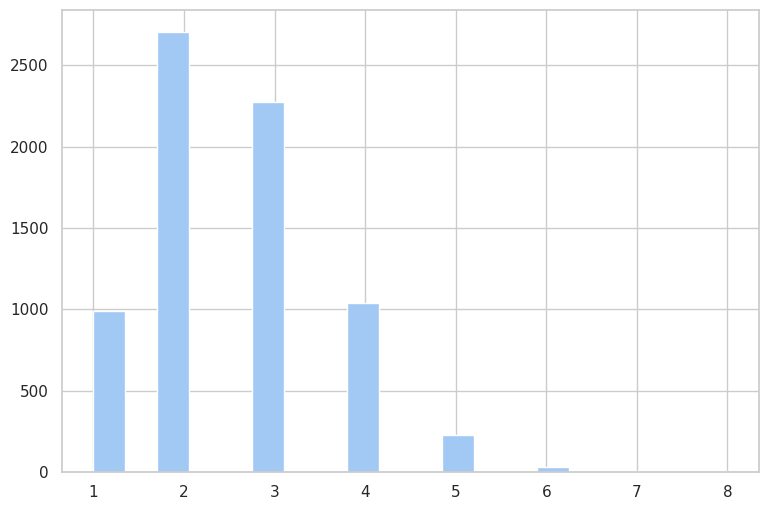

In [91]:
%matplotlib inline
df_r=df_n[['rooms']]
df_r['rooms'].hist(bins=20, figsize=(9,6))
plt.show()

Uylarning katta qismi 2 xonlidan 4 xonaligacha ekanini ko'rishimiz mumkin.

# UY NARXIGA ENG KO'P TASIR QILADIGAN PARAMETRLARNI KO'RIB CHIQAMIZ

In [92]:
df_1.corrwith(df_1['price']).sort_values(ascending=False)

,0
price,1.000000
size,0.787158
rooms,0.603204
max_levels,0.268437
level,0.085466


Bu ro'yxatimizda uylarning maydoni va xonalar soni uy narxini asosiy belgilab beruvchi parametrlar ekanini ko'ramiz.

# Uy narxiga eng katta ta'sir qiluvchi omil bu uy maydonlari ekan. Ushbu grafigimizda bu narsa judaham yaxshi ko'rinib turibdi.

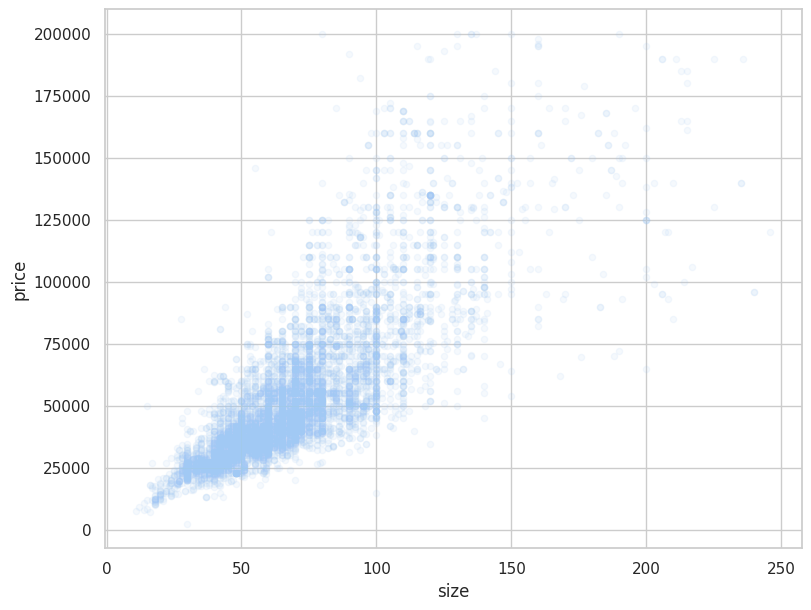

In [94]:
df_n.plot(kind='scatter', x="size", y="price", alpha=0.1, figsize=(9,7))
plt.show()

#Ma`lumotlarni ML uchun tayyolrash

In [95]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


In [96]:
from sklearn.base import BaseEstimator, TransformerMixin
size_ix, price_ix = 3, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        df_n = X.copy()
        df_f = df_n.drop(['location', 'district'], axis=1)
        for col in df_f.columns:
            if df_f[col].dtype == 'object':
                df_n[col] = pd.to_numeric(df_f[col], errors='coerce')
        df_n = df_n.dropna()
        df_n = df_n.drop(df_n[df_n['size']<15][df_n['rooms']>1].index)
        df_n = df_n.drop(df_n[df_n['size']>250].index)
        df_n = df_n.drop(df_n[df_n['size']==2100].index)
        df_n = df_n.drop(df_n[df_n['price']<7000][df_n['rooms']>1].index)
        df_n = df_n.drop(df_n[df_n['price']>200000].index)
        return df_n

combined_adder = CombinedAttributesAdder()

transformed_data = combined_adder.transform(df)

df_n = transformed_data

/tmp/ipykernel_5774/116473704.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_n = df_n.drop(df_n[df_n['size']<15][df_n['rooms']>1].index)
/tmp/ipykernel_5774/116473704.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_n = df_n.drop(df_n[df_n['price']<7000][df_n['rooms']>1].index)


In [97]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df_n, test_size=0.2, random_state=42)

X_train = train_set.drop("price", axis=1)
y = train_set["price"].copy()

X_num = X_train.drop(["district",'location'], axis=1)

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

num_pipeline = Pipeline([
          ('std_scaler', StandardScaler())
])

In [99]:
from sklearn.compose import ColumnTransformer

num_attribs = list(X_num)
cat_attribs = ['district']

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OrdinalEncoder(), cat_attribs)
])

In [100]:
X_prepared = full_pipeline.fit_transform(X_train)
X_prepared[0:5,:]

array([[ 1.38904861e+00,  2.26157807e+00,  5.88274615e-01,
        -3.01186764e-03,  9.00000000e+00],
       [-5.51946480e-01, -3.42901073e-01,  1.92633657e+00,
         1.13881335e+00,  2.00000000e+00],
       [-5.51946480e-01, -6.90164959e-01,  1.42253963e-01,
        -7.64228676e-01,  1.10000000e+01],
       [-5.51946480e-01, -1.69269130e-01, -1.19580799e+00,
         1.13881335e+00,  2.00000000e+00],
       [ 1.38904861e+00,  9.07248915e-01,  1.92633657e+00,
         1.13881335e+00,  4.00000000e+00]])

# Machine Learning

LinearRegression

In [101]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()

In [102]:
LR_model.fit(X_prepared, y)

LinearRegression()

In [103]:
# tasodifiy 5 ta qatorni ajratib olamiz
test_data = X_train.sample(5)
test_data

,location,district,rooms,size,level,max_levels
6261,"город Ташкент, Чиланзарский район, Лутфи",Чиланзарский,2,63.0,2,5
2747,"город Ташкент, Учтепинский район, Чиланзар 13-...",Учтепинский,4,90.0,5,5
4640,"город Ташкент, Олмазорский район, Каракамыш-1/4",Олмазорский,2,60.0,4,5
4705,"город Ташкент, Мирабадский район, Фаровон",Мирабадский,3,75.0,8,9
4682,"город Ташкент, Олмазорский район, Бируни-3 Олм...",Олмазорский,2,56.0,2,5


In [104]:
# yuqoridagi qatorlarga mos keluvchi narxlarni ajratib olamiz (biz aynan shu qiymatlarni bashorat qilishimiz kerak)
test_label = y.loc[test_data.index]
test_label

,price
6261,46500.0
2747,42500.0
4640,33000.0
4705,65000.0
4682,38000.0


In [105]:
test_data_prepared = full_pipeline.transform(test_data)
test_data_prepared

array([[-0.55194648, -0.23872191, -0.74978734, -0.38362027,  6.        ],
       [ 1.38904861,  0.69889058,  0.58827461, -0.38362027,  5.        ],
       [-0.55194648, -0.34290107,  0.14225396, -0.38362027,  3.        ],
       [ 0.41855107,  0.17799476,  1.92633657,  1.13881335,  1.        ],
       [-0.55194648, -0.48180663, -0.74978734, -0.38362027,  3.        ]])

In [106]:
predicted_data = LR_model.predict(test_data_prepared)
predicted_data

array([51231.94490688, 64503.01306794, 46766.57868666, 55516.33379843,
       46353.35097039])

In [107]:
pd.DataFrame({'Prognoz':predicted_data, 'Real baxosi': test_label})

,Prognoz,Real baxosi
6261,51231.944907,46500.0
2747,64503.013068,42500.0
4640,46766.578687,33000.0
4705,55516.333798,65000.0
4682,46353.350970,38000.0


In [108]:
test_set

,location,district,rooms,size,level,max_levels,price
1453,"город Ташкент, Чиланзарский район, Чиланзар 8-...",Чиланзарский,1,40.0,1,4,28500.0
4817,"город Ташкент, Мирзо-Улугбекский район, ОВИР",Мирзо-Улугбекский,1,30.0,2,4,30000.0
2973,"город Ташкент, Чиланзарский район, Чиланзар 5-...",Чиланзарский,2,52.0,1,4,41000.0
4252,"город Ташкент, Мирзо-Улугбекский район, Паркент",Мирзо-Улугбекский,3,115.0,2,9,115000.0
4134,"город Ташкент, Чиланзарский район, Чиланзар",Чиланзарский,1,42.0,4,9,28500.0
...,...,...,...,...,...,...,...
3598,"город Ташкент, Учтепинский район, Чиланзар 22-...",Учтепинский,3,68.0,2,4,40000.0
294,"город Ташкент, Чиланзарский район, Чиланзар 6-...",Чиланзарский,2,44.0,1,4,38000.0
2115,"город Ташкент, Юнусабадский район, Ислама Кари...",Юнусабадский,3,125.0,5,9,110000.0
2392,"город Ташкент, Олмазорский район, Каракамыш кв...",Олмазорский,1,42.0,4,5,22800.0


In [109]:
X_test = test_set.drop('price', axis=1)
X_test

,location,district,rooms,size,level,max_levels
1453,"город Ташкент, Чиланзарский район, Чиланзар 8-...",Чиланзарский,1,40.0,1,4
4817,"город Ташкент, Мирзо-Улугбекский район, ОВИР",Мирзо-Улугбекский,1,30.0,2,4
2973,"город Ташкент, Чиланзарский район, Чиланзар 5-...",Чиланзарский,2,52.0,1,4
4252,"город Ташкент, Мирзо-Улугбекский район, Паркент",Мирзо-Улугбекский,3,115.0,2,9
4134,"город Ташкент, Чиланзарский район, Чиланзар",Чиланзарский,1,42.0,4,9
...,...,...,...,...,...,...
3598,"город Ташкент, Учтепинский район, Чиланзар 22-...",Учтепинский,3,68.0,2,4
294,"город Ташкент, Чиланзарский район, Чиланзар 6-...",Чиланзарский,2,44.0,1,4
2115,"город Ташкент, Юнусабадский район, Ислама Кари...",Юнусабадский,3,125.0,5,9
2392,"город Ташкент, Олмазорский район, Каракамыш кв...",Олмазорский,1,42.0,4,5


In [110]:
y_test = test_set['price'].copy()
y_test

,price
1453,28500.0
4817,30000.0
2973,41000.0
4252,115000.0
4134,28500.0
...,...
3598,40000.0
294,38000.0
2115,110000.0
2392,22800.0


In [111]:
X_test_prepared = full_pipeline.transform(X_test)

In [112]:
y_predicted = LR_model.predict(X_test_prepared)

In [113]:
from sklearn.metrics import mean_squared_error
lin_mse = mean_squared_error(y_test, y_predicted)
# RMSE hisoblaymiz
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

17941.86731818831


In [114]:
from sklearn.tree import DecisionTreeRegressor
Tree_model = DecisionTreeRegressor()
Tree_model.fit(X_prepared, y)

DecisionTreeRegressor()

In [115]:
y_predicted = Tree_model.predict(X_test_prepared)

In [116]:
lin_mse = mean_squared_error(y_test, y_predicted)
# RMSE hisoblaymiz
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

17744.91535251343


In [117]:
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor()
RF_model.fit(X_prepared, y)

RandomForestRegressor()

In [118]:
y_predicted = RF_model.predict(X_test_prepared)
lin_mse = mean_squared_error(y_test, y_predicted)
# RMSE hisoblaymiz
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

14157.452806235651


In [119]:
X = df_n.drop("price", axis=1)
y = df_n["price"].copy()

X_prepared = full_pipeline.transform(X)

In [120]:
X = df_n.drop("price", axis=1)
y = df_n["price"].copy()

X_prepared = full_pipeline.transform(X)

In [121]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Std.dev:", scores.std())

In [122]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LR_model, X_prepared, y, scoring="neg_mean_squared_error", cv=10)
LR_rmse_scores = np.sqrt(-scores)

In [123]:
display_scores(LR_rmse_scores)

Scores: [15503.57062689 16322.65299131 19568.70800942 19487.73430478
 19613.89627834 19904.17506981 16581.96463684 15840.15278261
 18323.50189642 16111.99997825]
Mean: 17725.835657468433
Std.dev: 1718.8279629518222


In [124]:
scores = cross_val_score(Tree_model, X_prepared, y, scoring="neg_mean_squared_error", cv=10)
LR_rmse_scores = np.sqrt(-scores)
display_scores(LR_rmse_scores)

Scores: [15357.60628175 15621.9924815  21151.58551079 20034.36451533
 20567.96757841 18729.90963004 18338.4808429  16932.6767848
 18715.47545423 16556.53722032]
Mean: 18200.65963000742
Std.dev: 1930.8577177660577


In [125]:
scores = cross_val_score(RF_model, X_prepared, y, scoring="neg_mean_squared_error", cv=10)
LR_rmse_scores = np.sqrt(-scores)
display_scores(LR_rmse_scores)

Scores: [12269.20546516 13310.01715723 16660.7722346  17074.07175105
 16696.0369153  15291.32921946 13710.62538626 13240.01048069
 14190.00374995 13471.67748877]
Mean: 14591.374984846796
Std.dev: 1625.3246559464883
